# Análisis exploratorio de datos | Datos históricos del precio del Bitcoin



## Introducción y contexto
### Objetivo del análisis

#### Objetivo general
- Comprender la estructura y características generales de la serie histórica de precios del Bitcoin.

#### Objetivos específicos
- Deescribir las principales caracteristicas del conjunto de datos como su estructura, dimensiones, datos faltantes buscando identificar mediante el análisis de funciones de autocorrelación y agrupaciones temporales las frecuencias más dominantes.
- Analizar la tendencia a largo plazo de la serie, aplicando métodos de suavizamineto, pruebas de estacionariedad y transformaciones de datos para corregir cambios en la media y varianza en el timepo
- Examinar anomalias o eventos extremos contextualizacion los posibles eventos externos relevantes
- Sintetizar los resultados más relevantes y las problemáticas detectadas construyendo recomendaciones para la siguiente fase del proyecto.

### Descripción de los datos
El Bitcoin es una criptomoneda descentralizada nacida en el año 2008 por una entidad conocida como Satoshi Nakamoto. Su principal diferenciador frente a las monedas tradicionales y reguladas, es el uso de blockchain para poder realizar transferencias bancarias sin necesidad de tener un intermediario financiero. Su popularidad de debe a su alta volatilidad, alzas astronómicas en su valor durante la pandemia, una oferta limitada de 21 millones de unidades, e inmediatez en las transacciones globales.
El conjunto de datos escogido para ser utilizados en este proyecto es titulado "Bitcoin Historical Data" y fue publicado en la Kaggle, una de las comunidades para cientificos de datos más populares en todo el mundo. El dataset presenta una serie temporal que describe desde el año 2012 el precio registrado del Bitcoin frente al dólar estadounidense registrado por minuto, lo cual permite explorar con mucha granularidad el comportamiento de la serie. Adicionalmente, resulta importante mencionar qué variables ayudan a describir los datos:

- Open: Precio de apertura
- High: Precio máximo en una ventana de tiempo 
- Low: Precio minimo en una ventana de tiempo 
- Close: Precio de cierre
- Volume: Volumen de BTC transaccionado en la ventana de tiempo 

Resulta importante resaltar que los precios están expresados en dólares estadounidenses (USD) y el volumen representa la cantidad de Bitcoin negociada (BTC). 

## Análisis preliminar

### Inspección general
#### Dimensiones del conjunto de datos
Primero, se revisa la dimensión general del dataset. Este paso resulta relevante para poder establecer la complejidad computacional del ejercico

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from tabulate import tabulate

In [4]:
datos = pd.read_csv('/Users/pctm/Desktop/Universidad/Sem 6/btcusd_1-min_data.csv')
pd.options.display.float_format = '{:,.2f}'.format
print(datos.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7457440 entries, 0 to 7457439
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 341.4 MB
None


Como vemos, el presente dataset cuenta con 7.457.440 observaciones descritas con la ayuda de 6 variables:
- **Timestamp**: Contiene información sobre la ventana de tiempo referencia de cada observación.
- **Open**: Precio de apertura
- **High**: Precio máximo en una ventana de tiempo 
- **Low**: Precio minimo en una ventana de tiempo 
- **Close**: Precio de cierre
- **Volume**: Volumen de BTC transaccionado en la ventana de tiempo 


## Dimensiones del conjunto de datos a utilizar
Para el presente proyecto, solamente se tendrán en cuenta los datos registrados desde el año 2019 y serán agrupados en intervalos de 15 minutos. Esto se hará con el objetivo de estudiar el comportamiento más reciente de la distribución y para adaptar el costo computacional del estudio a las capacidades actuales de nuestras herramientas.

In [5]:
datos["TimestampConventional"] = pd.to_datetime(datos["Timestamp"], unit="s")
datos.set_index("TimestampConventional", inplace=True)

df = datos['2019':][["Open","High","Low","Close", "Volume"]].resample('15T').mean()
df.info()


/var/folders/x3/pv5pxgpn24d3dg_tsmkjptgc0000gn/T/ipykernel_71994/2493197735.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = datos['2019':][["Open","High","Low","Close", "Volume"]].resample('15T').mean()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251809 entries, 2019-01-01 00:00:00 to 2026-03-08 00:00:00
Freq: 15min
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Open    251733 non-null  float64
 1   High    251733 non-null  float64
 2   Low     251733 non-null  float64
 3   Close   251733 non-null  float64
 4   Volume  251733 non-null  float64
dtypes: float64(5)
memory usage: 11.5 MB


Ahora, se cuenta con un total de 251.733 observaciones. Adicionalmente, dado que la variable tiempo está almacenada en formato de timestamp Unix, se añadió una nueva columna llamada TimestampConventional con un formato de fecha y hora más legible para mejorar la claridad del análisis.

#### Primeros y ultimos valores
A continuación se procede a revisar los primeros y ultimos registros para verificar la coherencia temporal

In [6]:
print(df.head())
print(df.tail())

                          Open     High      Low    Close  Volume
TimestampConventional                                            
2019-01-01 00:00:00   3,746.45 3,747.96 3,744.77 3,746.23    7.07
2019-01-01 00:15:00   3,742.76 3,743.50 3,741.85 3,742.40    1.96
2019-01-01 00:30:00   3,740.07 3,741.80 3,733.33 3,734.86    9.68
2019-01-01 00:45:00   3,670.15 3,679.61 3,663.98 3,672.69   21.49
2019-01-01 01:00:00   3,679.57 3,683.13 3,676.71 3,680.01    5.89
                           Open      High       Low     Close  Volume
TimestampConventional                                                
2026-03-07 23:00:00   67,316.73 67,335.07 67,306.00 67,319.87    0.54
2026-03-07 23:15:00   67,353.80 67,365.60 67,347.80 67,358.00    0.47
2026-03-07 23:30:00   67,358.53 67,365.20 67,349.53 67,356.53    0.97
2026-03-07 23:45:00   67,284.80 67,290.07 67,277.00 67,281.07    0.66
2026-03-08 00:00:00   67,269.00 67,308.00 67,269.00 67,308.00    0.54


Luego de la conversión, se puede ver que el inicio de la recopilación de los datos comienza desde el primero de enero del año 2019, mientras el último registro coincide con el 7 de marzo.

#### Identificación de valores faltantes
Finalmente, en esta sección se revisarán los valores faltantes de la serie.

In [7]:
print(df.isna().sum(), "valores faltantes")
print(df.isna().sum() / len(df) * 100, "% de valores faltantes")

faltantes = df[df.isna()]
print(faltantes)


Open      76
High      76
Low       76
Close     76
Volume    76
dtype: int64 valores faltantes
Open     0.03
High     0.03
Low      0.03
Close    0.03
Volume   0.03
dtype: float64 % de valores faltantes
                       Open  High  Low  Close  Volume
TimestampConventional                                
2019-01-01 00:00:00     NaN   NaN  NaN    NaN     NaN
2019-01-01 00:15:00     NaN   NaN  NaN    NaN     NaN
2019-01-01 00:30:00     NaN   NaN  NaN    NaN     NaN
2019-01-01 00:45:00     NaN   NaN  NaN    NaN     NaN
2019-01-01 01:00:00     NaN   NaN  NaN    NaN     NaN
...                     ...   ...  ...    ...     ...
2026-03-07 23:00:00     NaN   NaN  NaN    NaN     NaN
2026-03-07 23:15:00     NaN   NaN  NaN    NaN     NaN
2026-03-07 23:30:00     NaN   NaN  NaN    NaN     NaN
2026-03-07 23:45:00     NaN   NaN  NaN    NaN     NaN
2026-03-08 00:00:00     NaN   NaN  NaN    NaN     NaN

[251809 rows x 5 columns]


De un total de 250.000 observaciones aproximadamente, se encontraron 76 valores faltantes. Esto es menor a un 0.03% del total. Al tratarse de un porcentaje muy inferior y además por tratarse de datos daltantes en una única fecha se procedió a eliminarlos.

In [8]:
df = df.dropna()
print(df.isna().sum(), "valores faltantes después de eliminar")

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64 valores faltantes después de eliminar


### Inspección general
#### Medidas básicas
Se procederá a conocer las medidas descriptivas básicas del conjunto de datos con el objetivo de tener una primera aproximación al mercado de Bitcoin durante el periodo analizado. Estas incluyen: media, mediana, desviación estándar, minimo, máximo y percentiles.

In [9]:
cols = ["Open","High","Low","Close","Volume"]
print(df[cols].describe().T)

            count      mean       std      min       25%       50%       75%  \
Open   251,733.00 42,412.20 32,446.77 3,350.17 12,246.59 34,114.97 62,938.47   
High   251,733.00 42,426.54 32,454.25 3,351.75 12,253.36 34,132.27 62,955.20   
Low    251,733.00 42,397.67 32,439.18 3,350.00 12,236.10 34,098.47 62,921.80   
Close  251,733.00 42,412.23 32,446.76 3,351.37 12,247.46 34,118.73 62,939.51   
Volume 251,733.00      2.93      5.94     0.00      0.42      1.19      3.14   

              max  
Open   125,906.00  
High   125,959.67  
Low    125,863.60  
Close  125,927.67  
Volume     270.20  


Se puede ver que las variables de precio Open, High, Low y Close presentan valores promedio cercanos a 42.000 USD con una desviación estándar aproximada de 33.000 USD, lo cual podría indicar una alta volatilidad en su precio en el transcurso de los años. El valor minimo registrado corresponde a 3.300 dólares y su máximo a 126.000 dólares. Incluso los percentiles coinciden, con un 25% de los precios menores a 12.200 USD y un 75% por debajo de 63.000 dólares. La mediana o el 50% de los datos se sitúa cerca a 34.100 USD.

Por otro lado, para la variable Volume, se tiene una media de aproximadamente 2.93, con una desviación estándar de 5.94. Presenta valores mínimos cercanos a 0 y máximos que superan 270, lo cual indica la posible presencia de periodos con actividad de mercado mucho más alta. La mediana de los datos se encuentra en 1.19. 

#### Métricas de dispersión 
Para profundizar el análisis se procederá a calcular el rango intercuartilico con el objetivo de medir la dispersión de los valores centrales de la distribución.

In [10]:
cols = ["Open","High","Low","Close","Volume"]

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

Open     50,691.88
High     50,701.84
Low      50,685.70
Close    50,692.05
Volume        2.72
dtype: float64


En el caso de las variables de precio Open, High, Low y Close se puede observar que el valor del rango intercuartilico es aproximadamente de 50.000 USD, lo cual confirma una alta volatilidad de su precio a lo largo del tiempo. Por otro lado, el Volume tiene un IQR de 2.72 que al compararse con su valor máximo, podría interpretarse como un rango reducido, con una presencia de valores extremos o picos de actividad.

## Visualización de la serie

### Visualización temporal
#### Gráfica de linea
A continuación, se procederá a construir la primera visualización de la serie.

In [11]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


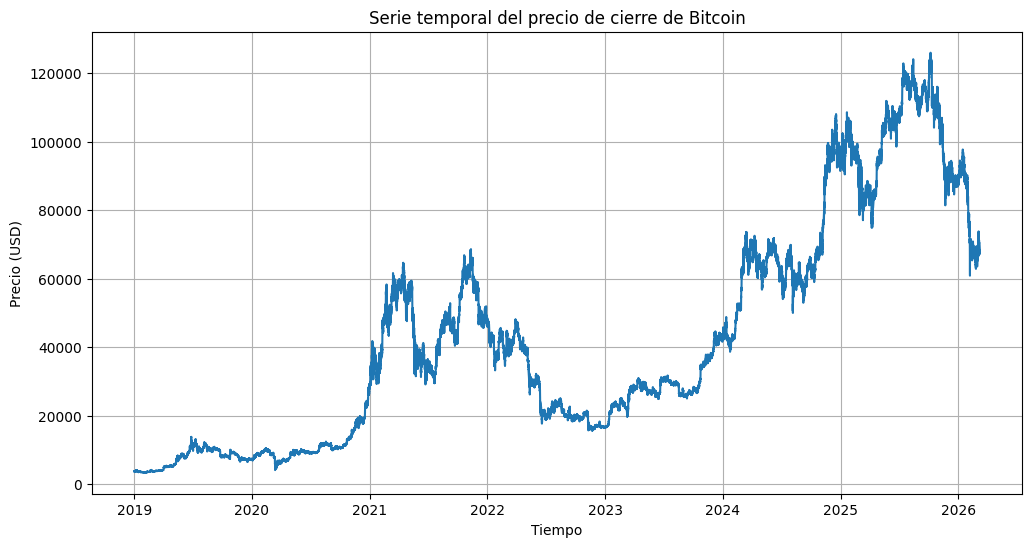

In [12]:

df = df.sort_index()

plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'])

plt.title("Serie temporal del precio de cierre de Bitcoin")
plt.xlabel("Tiempo")
plt.ylabel("Precio (USD)")
plt.grid(True)

plt.show()

Este gráfico presenta la evolución general del precio de cierre del Bitcoin frente al dolar desde el año 2019. Se puede ver que hubo un aumento considerable de su precio desde el año 2010, hasta llegar a su máximo histórico a finales del año 2025. Posteriormente se ha visto una correción de su precio, reflejando la volatilidad característica del mercado de criptomonedas.

#### Gráfica desagregada
#### Precios

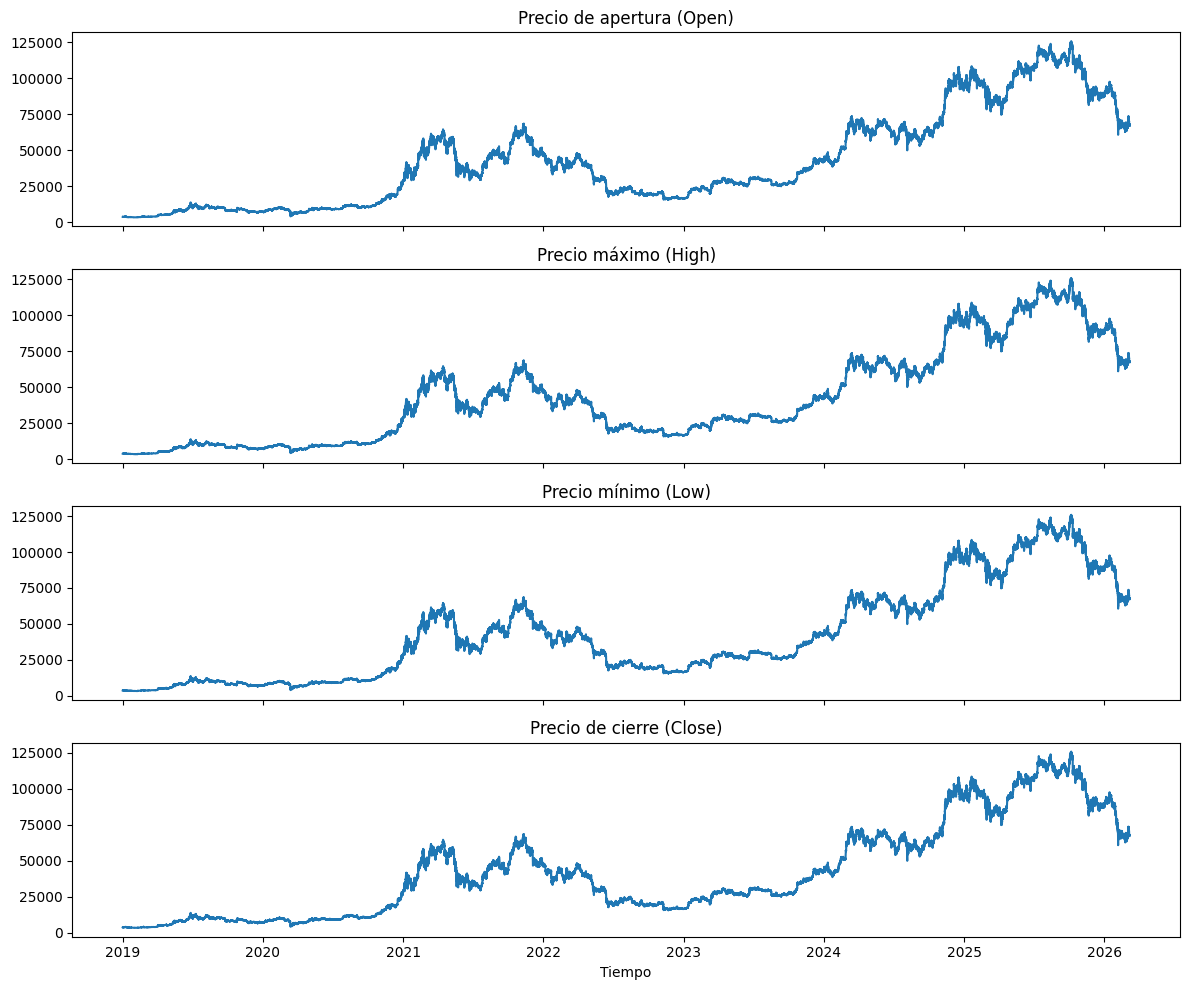

In [13]:
fig, axes = plt.subplots(4,1, figsize=(12,10), sharex=True)

axes[0].plot(df.index, df['Open'])
axes[0].set_title("Precio de apertura (Open)")

axes[1].plot(df.index  , df['High'])
axes[1].set_title("Precio máximo (High)")

axes[2].plot(df.index, df['Low'])
axes[2].set_title("Precio mínimo (Low)")

axes[3].plot(df.index, df['Close'])
axes[3].set_title("Precio de cierre (Close)")

plt.xlabel("Tiempo")
plt.tight_layout()
plt.show()

Las series correspondientes al precio de apertura, máximo, mínimo y cierre presentan comportamientos extremadamente similares al tratarse del mismo activo en un intervalo temporal muy corto. Se ven las mismas tendencias y eventualidades descritas previamente.

#### Volumen

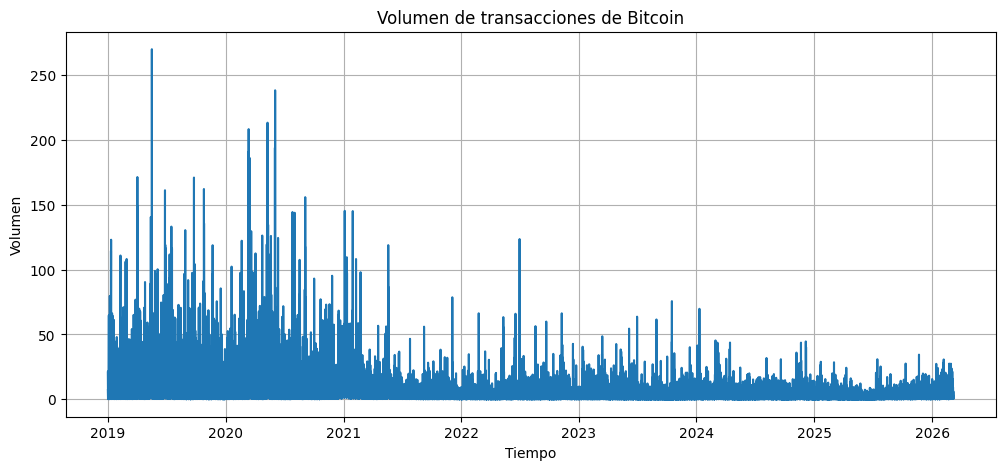

In [14]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Volume'])

plt.title("Volumen de transacciones de Bitcoin")
plt.xlabel("Tiempo")
plt.ylabel("Volumen")
plt.grid(True)

plt.show()

Por otro lado, el volumen presenta un comportamiento distinto a las demás variables con picos de gran volumen entre 2019 y 2021, lo cual podría hacer referencia a altos picos de actividad en ese periodo de tiempo. Esto se ve seguido a una disminución en los años 2022 y 2023, mientras que a partir de 2025, el volumen es mucho más bajo y estable.

### Análisis de componentes (Descomposición clásica)
El análisis de componentes de series temporales se define como la descomposición de la serie en elementos que permiten describir adecuadamente los patrones que la conforman. Generalmente una serie se descompone en: tendencia, estacionalidad y residuales. Para hacer la descomposición se utilizará la función *seasonal_decompose* que nos permitirá fraccionar la serie en sus componentes esenciales utilizando una descomposición clásica.

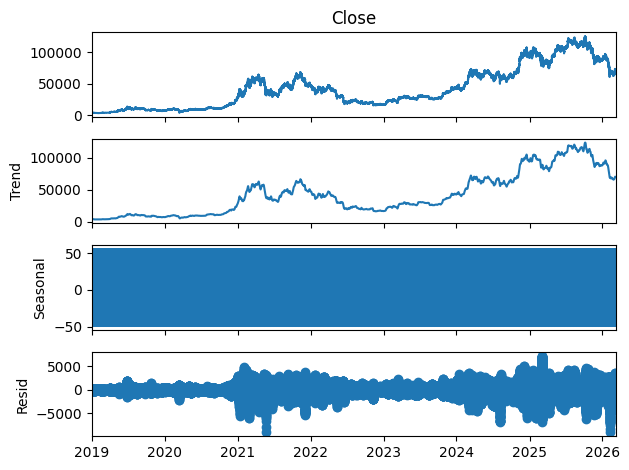

In [15]:
df = df.sort_index() 

from statsmodels.tsa.seasonal import seasonal_decompose

serie = df['Close'] 

decomposition = seasonal_decompose(serie, model='additive', period=365)

decomposition.plot()
plt.tight_layout()
plt.show()

#### Tendencia
La tendencia permite observar la evolución general del precio del Bitcoin, en esta ocasión, se utilizó el valor final en cada intervalo de tiempo. La función elimina las fluctuaciones de corto plazo presentes en la serie original y muestra el comportamiento estructural del mercado. Como se ve en el gráfico, la tendencia muestra un crecimiento notable en varios periodos, seguidos de épocas de correción dada la naturaleza correctiva de de los mercados financieros.


#### Estacionalidad
Describe qué tan seguido se presentan los patrones estacionales en una serie temporal. En activos financieros es normal que dependiendo su volatilidad no se presenten patrones estacionales. El segundo gráfico es practicamente plano, lo cual indica que el Bitcoin no tiene patrones estacionales anuales o mensuales, esto permite concluir que la variación está dominada más por eventos de mercado que por ciclos periódicos predecibles.

#### Residuales
Los residuales están compuestos por lo que queda de la serie luego de quitar la tendencia y la estacionalidad. En otras palabras, representan el ruido del mercado. En el tercer gráfico se puede ver que se tienen fluctuaciones significativas alrededor de 2021 a 2025, probablemente marcados por algún evento inesperado. Se puede concluir que, los picos de precios no siguen un patrón regular y están marcados por una alta volatilidad.

### Análisis de componentes (STL)
La descomposición clásica es una herramienta bastante útil para poder conocer como se compone una serie de tiempo, sin embargo, posee algunas limitaciones como un manejo limitado de outliers, una tendencia lineal y estacionalidad fija. La descomposición STL es una técnica más flexible que utiliza suavizado Loess para extraer la tendencia y estacionalidad de una manera más efectiva en series cambiantes no lineales como las financieras.

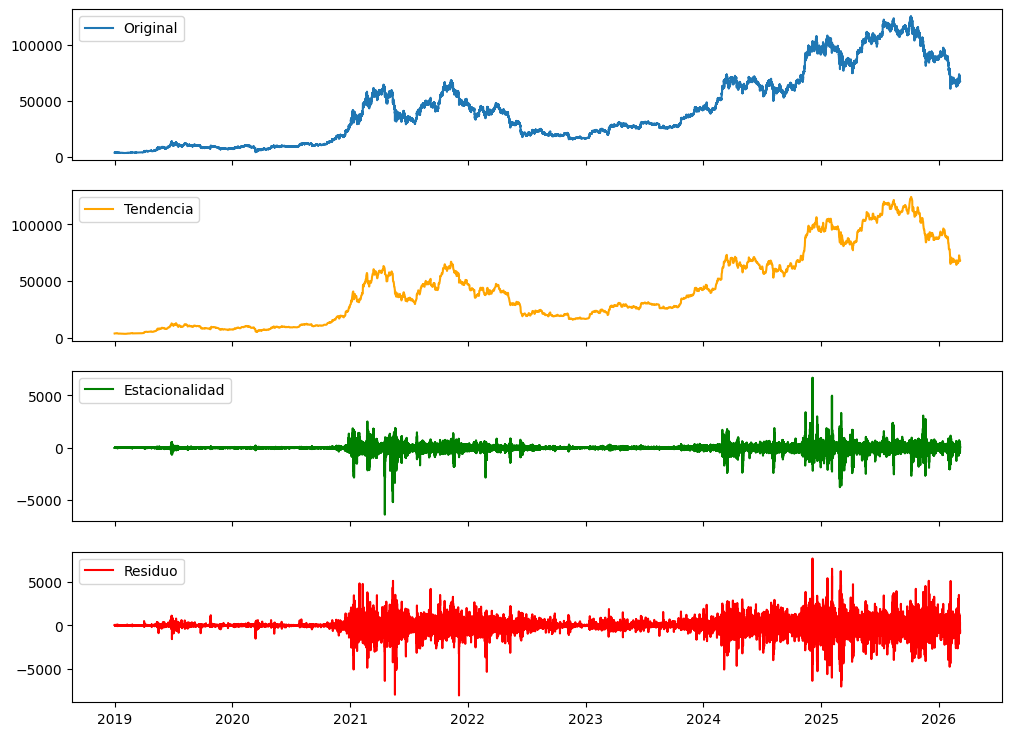

In [16]:
bitcoin_series = df['Close']  

stl = STL(bitcoin_series, period=48, robust=True)  
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(bitcoin_series, label='Original')
axes[0].legend(loc='upper left')
axes[1].plot(result.trend, label='Tendencia', color='orange')
axes[1].legend(loc='upper left')
axes[2].plot(result.seasonal, label='Estacionalidad', color='green')
axes[2].legend(loc='upper left')
axes[3].plot(result.resid, label='Residuo', color='red')
axes[3].legend(loc='upper left')
plt.show()

En esta ocasión, se configuró el STL para que capture ciclos cada 12 horas y busque patrones que se repitan en ese espacio de tiempo. En el resultado se presenta mucha similitud con respecto a la descomposición clásica en la distribución original y la tendencia, como los mismos picos alcistas en 2021 y 2025, seguidos de sus respectivos periodos de corrección. Por otro lado, para la estacionalidad se confirma que no es constante si no que escala con el precio, mientras que los residuos muestran eventos extremos en 2021 - 2022 y 2024 - 2025 coincidentes con los picos pronunciados en precio.

Dado que la amplitud de la estacionalidad y los residuos crecen proporcionalmente con respecto al precio, la varianza de la serie no es constante. Por lo que se procederá a realizar una transformación logaritmica para poder estabilizarla y hacer la descomposición más interpretable.

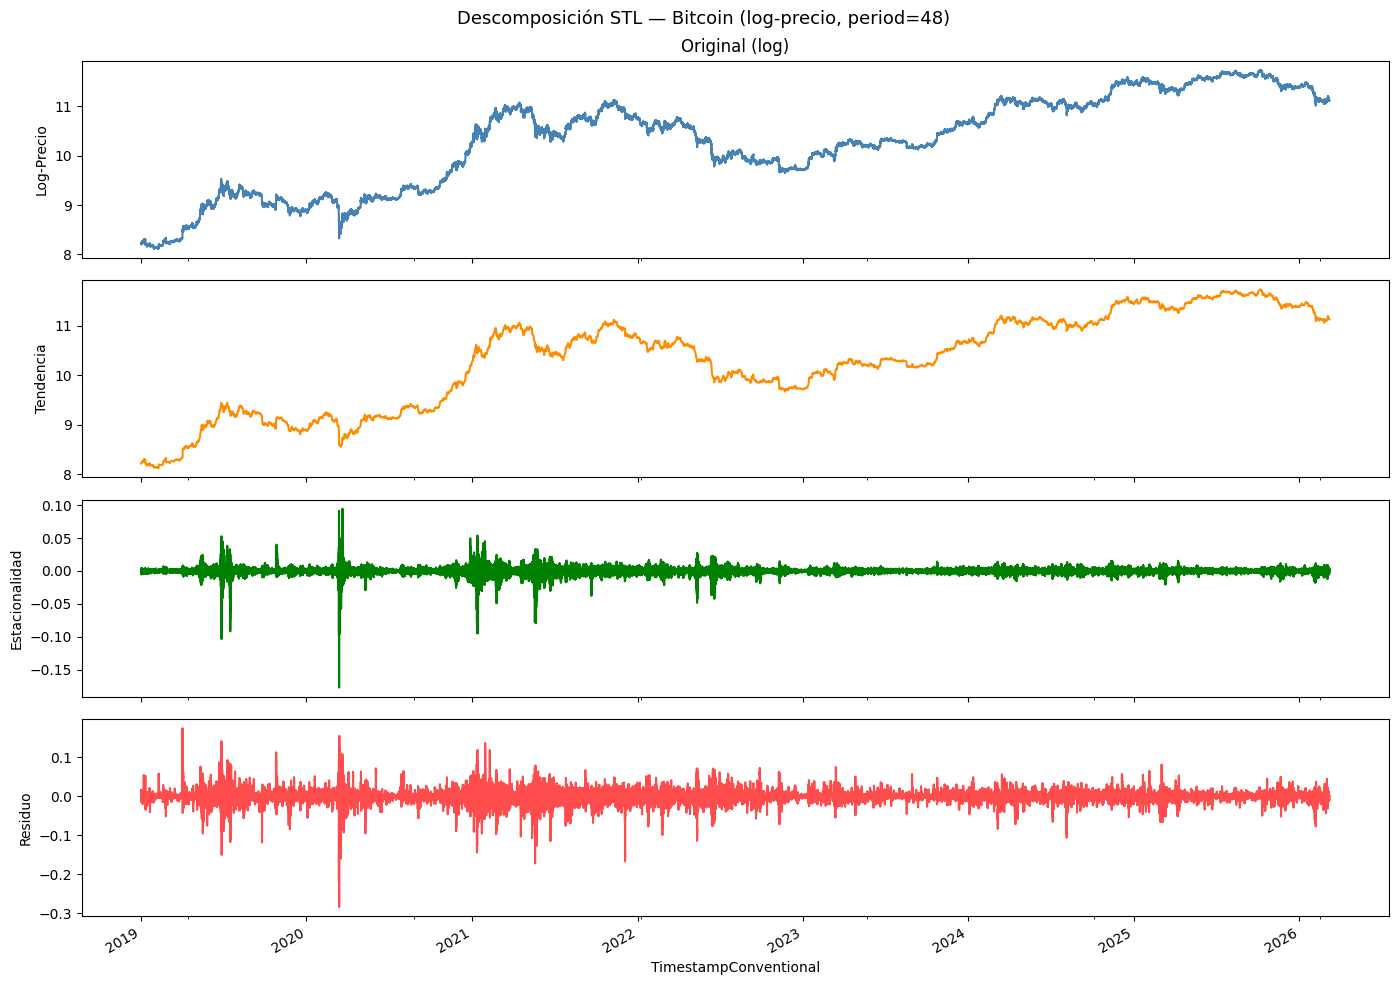

In [17]:

serie_log = np.log(df['Close'])

stl_log = STL(serie_log, period=48, robust=True)
result_log = stl_log.fit()

# Visualización
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

serie_log.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Log-Precio')
axes[0].set_title('Original (log)')

pd.Series(result_log.trend, index=serie_log.index).plot(ax=axes[1], color='darkorange')
axes[1].set_ylabel('Tendencia')

pd.Series(result_log.seasonal, index=serie_log.index).plot(ax=axes[2], color='green')
axes[2].set_ylabel('Estacionalidad')

pd.Series(result_log.resid, index=serie_log.index).plot(ax=axes[3], color='red', alpha=0.7)
axes[3].set_ylabel('Residuo')

plt.suptitle('Descomposición STL — Bitcoin (log-precio, period=48)', fontsize=13)
plt.tight_layout()
plt.show()

La serie original y la tendencia ahora muestan variaciones porcentuales en lugar de mostrar de absolutas, manteniendo los ciclos alcistas y bajistas visibles, sin embargo, las observaciones se muestran considerablemente mpas homogéneas. Lo mismo ocurre con la estacionalidad y residuo, ahora se distribuyen más homogéneamente alrededor de 0, con picos negativos pronunicados entre 2020 y 2021. Se concluye lo mismo, el Bitcoin no tiene una estacionalidad consistentemente fuerte.

### Detección de anomalías
Ahora, se estudiarán las anomalías o outliers presentes en la serie.

Número de días con outliers: 53


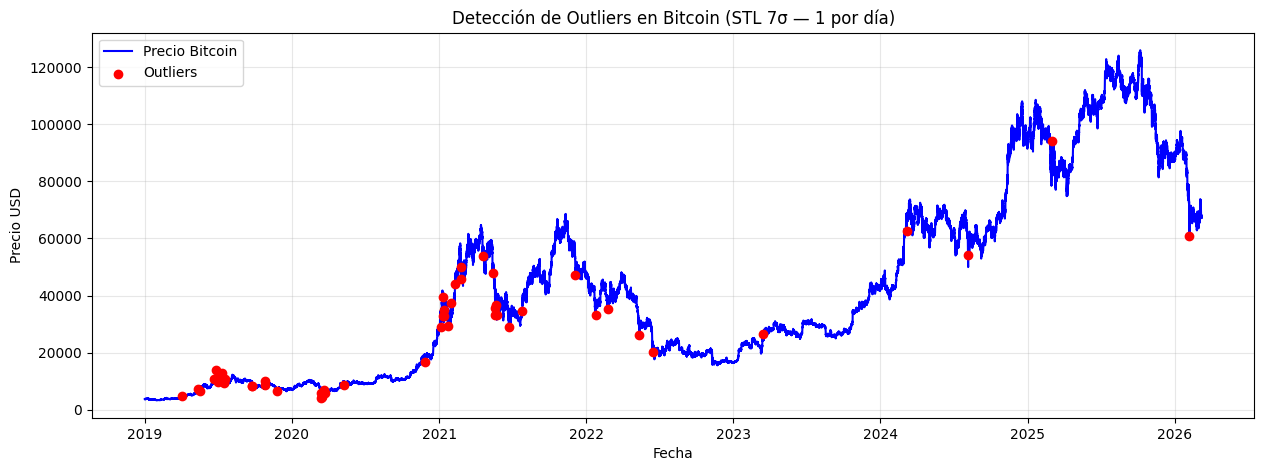

In [18]:
resid_log = pd.Series(result_log.resid, index=serie_log.index)

umbral = 7 * resid_log.std()
outliers = resid_log[abs(resid_log) > umbral]

outliers_diarios = outliers.groupby(outliers.index.date).apply(lambda x: x.abs().idxmax())
outliers_diarios = resid_log.loc[outliers_diarios.values]

print(f"Número de días con outliers: {len(outliers_diarios)}")

plt.figure(figsize=(15,5))
plt.plot(df.index, df['Close'], label='Precio Bitcoin', color='blue')
plt.scatter(outliers_diarios.index, df['Close'].loc[outliers_diarios.index],
            color='red', label='Outliers', zorder=5)
plt.title("Detección de Outliers en Bitcoin (STL 7σ — 1 por día)")
plt.xlabel("Fecha")
plt.ylabel("Precio USD")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
tabla_outliers = df['Close'].loc[outliers_diarios.index].reset_index()
tabla_outliers.columns = ['Fecha', 'Precio_USD']
tabla_outliers['Residuo'] = resid_log.loc[outliers_diarios.index].values
tabla_outliers['Tipo'] = tabla_outliers['Residuo'].apply(lambda x: '📈 Subida' if x > 0 else '📉 Caída')
tabla_outliers = tabla_outliers.sort_values('Fecha')
print(tabulate(tabla_outliers, headers='keys', tablefmt='pretty', showindex=False))

+---------------------+--------------------+----------------------+-----------+
|        Fecha        |     Precio_USD     |       Residuo        |   Tipo    |
+---------------------+--------------------+----------------------+-----------+
| 2019-04-02 09:15:00 | 4942.709333333333  | 0.17460716094019446  | 📈 Subida |
| 2019-05-12 03:15:00 |      7363.25       | 0.07612204953103152  | 📈 Subida |
| 2019-05-17 07:00:00 |      6709.574      | -0.09547746980701888 | 📉 Caída  |
| 2019-06-22 07:00:00 | 10813.155333333332 | 0.08710561407004569  | 📈 Subida |
| 2019-06-26 22:45:00 | 13793.564666666667 | 0.11414554837476665  | 📈 Subida |
| 2019-06-27 21:00:00 | 10709.368666666667 | -0.15024078882774283 | 📉 Caída  |
| 2019-06-28 01:45:00 | 10726.003999999999 | -0.0934216773212313  | 📉 Caída  |
| 2019-07-02 15:30:00 |      9741.858      | -0.08909776139518222 | 📉 Caída  |
| 2019-07-10 17:00:00 | 13053.740666666668 | 0.09277971632891813  | 📈 Subida |
| 2019-07-16 23:30:00 | 9613.808666666668  | -0.1

Para detectar los outliers, se utilizó la serie residual de la descomposición STL construida previamente. Los valores atípicos no se encuentran en la tendencia ni en la estacionalidad si no en lo que no se puede explicar de ambas, ahora, se utiliza el residuo de la transformación logaritmica porque los cambios relativos son comparables y la desviación ya no va a depender del nivel absoluto del precio. Finalmente, se utilizó un umbral alto y se agruparon los datos para reducir la gran cantidad de outliers encontrados en un día y hacer más preciso el resultado.

En total, se detectaron 53 eventos extremos entre 2019 y 2026. En el periodo de mitad de año de 2019 se concentraron muchas alzas y bajasndo a una subida de hasta casi 13000 USD, con su posterior corrección. En marzo 2020, hubo un crash provocado por el inicio de la cuarente provocada por la expansión del COVID-19, la cual está en linea con el colapso de todos los mercados financieros dada la coyuntura economica potenciada por la incertidumbre del momento. Durante 2021 hubo muchos movimientos extremos de tendencia alcista y bajistas marcados por la entrada de grandes inversores como Tesla y MicroStrategy, la prohibición de transacciónes con crypto en China, y la correción luego de su primer máximo histórico de 69.000 USD. En 2022, luego de otro pico histórico, se profundizó la tendencia bajista que se extendió hasta 2024. Hasta 2025 que solo fue testigo de un momento alcista hasta 2026 que se presentó otro evento extremo que marcó el inicio de una fase de corrección.